Possíveis análises:

- neighborhood x price
- OverallQual (avaliação do material geral e acabamento da casa) x Price
- OverallCond (avaliação do estado geral da casa) x Price
- YearBuilt (data de construção) e YearRemodAdd (Data de reforma) --> usar YearRemodAdd (se não houve reformas, é o msm de construção)
- histograma de Heating (tipo de aquecimento)?
- GrLivArea (area habitavel acima do solo em pés quadrados)
- LotArea (tamanho do lote)
- GarageArea
- BedroomAbvGr (quartos acima do chão)
- MSZoning (classificação geral de zoneamento da venda)
- Street (tipo de acesso rodoviario) e Alley (tipo de acesso à prioridade)
- HouseStyle
- ExterQual e ExterCond
- BsmtQual (qualidade do porão) --> avaliar se número de casas com porão é significativo o bastante
- TotalBsmtSF (total de pés quadrados da área do porão)
- Fireplace ?
- SaleType & SaleCondition ??
- Pensei em fazer um heatmap do preço das casas usando o mapa da cidade de Ames, mas num encontrei um mapa com informações dos bairros

In [11]:
import pandas as pd

houses = pd.read_csv('houses.csv', keep_default_na=False, na_values=['NA',''])
houses.head()

# Aqui, defini que apenas "NA" e '' serão considerados como valores nulos
# "None" não será considerado nulo pois, em todas colunas que aparece, tem significado

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Antes de iniciar a análise dos dados, é importante ter uma perspectiva sobre valores ausentes

In [12]:
def print_null_info(df):
    """Funçao para printar informações de valores nulos de um dataframe"""
    num_nulls = df.isnull().sum()
    num_nulls = num_nulls[num_nulls > 0]

    if num_nulls.empty:
        print("There are no Null values in dataframe.")
        return

    percent_nulls = (num_nulls / len(df)) * 100
    null_values_df = pd.DataFrame({
        'num_nulls': num_nulls,
        'percent_nulls': percent_nulls
    }).sort_values(by='num_nulls', ascending=False).reset_index()
    
    print(null_values_df)

# Verificando valores nulos do df houses:
print_null_info(houses)

           index  num_nulls  percent_nulls
0         PoolQC       1453      99.520548
1    MiscFeature       1406      96.301370
2          Alley       1369      93.767123
3          Fence       1179      80.753425
4    FireplaceQu        690      47.260274
5    LotFrontage        259      17.739726
6     GarageCond         81       5.547945
7     GarageType         81       5.547945
8    GarageYrBlt         81       5.547945
9   GarageFinish         81       5.547945
10    GarageQual         81       5.547945
11  BsmtFinType2         38       2.602740
12  BsmtExposure         38       2.602740
13      BsmtCond         37       2.534247
14      BsmtQual         37       2.534247
15  BsmtFinType1         37       2.534247
16    MasVnrType          8       0.547945
17    MasVnrArea          8       0.547945
18    Electrical          1       0.068493


Depending on the description of the variable, missing values may have a specific meaning:

- ``PoolQC``: No pool 
- ``MiscFeature``: No additional feature
- ``Alley``: No access
- ``Fence``: No fence
- ``FireplaceQu``: No fireplace
- ``LotFrontage``: MISSING VALUE!!
- ``GarageFinish``, ``GarageQual``, ``GarageYrBlt``, ``GarageType``, ``GarageCond`` : No garage
- ``BsmtExposure``, ``BsmtFinType2``, ``BsmtCond``, ``BsmtFinType1``, ``BsmtQual``: No basement
- ``MasVnrArea``: MISSING VALUE!!
- ``MasVnrType``: MISSING VALUE!!
- ``Electrical``: MISSING VALUE!!

For the variables that ``NA`` has a meaning, we can substitute ``NA`` with ``None``, so that ``NA`` stay reserved for actual missing values.


In [13]:
meaningfull_NA_list = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

# Substituindo NA por None nas colunas onde NA tem significado
for column in meaningfull_NA_list:
    houses[column] = houses[column].fillna('None')

# Como "GarageYrBlt" é uma variável numérica, não faz sentido substituir NA por None
# Substituo por 0 para indicar que não tem garagem
houses['GarageYrBlt'] = houses['GarageYrBlt'].fillna(0)

print_null_info(houses)

         index  num_nulls  percent_nulls
0  LotFrontage        259      17.739726
1   MasVnrType          8       0.547945
2   MasVnrArea          8       0.547945
3   Electrical          1       0.068493


For the variables that ``NA`` simply means a missing value, we can substitue ``NA`` with the median value. Although it may not be the most sofisticate way to impute values, it is more immune to extreme values than the mean value.

In [14]:
# Substituindo valores ausentes de LotFrontage pela mediana
lotfrontage_median = houses['LotFrontage'].median()
houses['LotFrontage'] = houses['LotFrontage'].fillna(lotfrontage_median)

print(f"LotFrontage median used for imputation: {lotfrontage_median:.2f}")
print(f"Remaining missing values in LotFrontage: {houses['LotFrontage'].isna().sum()}")

LotFrontage median used for imputation: 69.00
Remaining missing values in LotFrontage: 0


In [15]:
# Identificando variáveis numéricas, categóricas e ordinais
numerical_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'FullBath', 'HalfBath']
categorical_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']
ordinal_cols = ['LotShape', 'LandSlope','OverallQual','YearBuilt','YearRemodAdd', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu','GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MoSold', 'YrSold']

# numero total de variáveis numéricas, categóricas e ordinais
print(f"Total columns: {len(numerical_cols) + len(categorical_cols) + len(ordinal_cols)}")

Total columns: 80


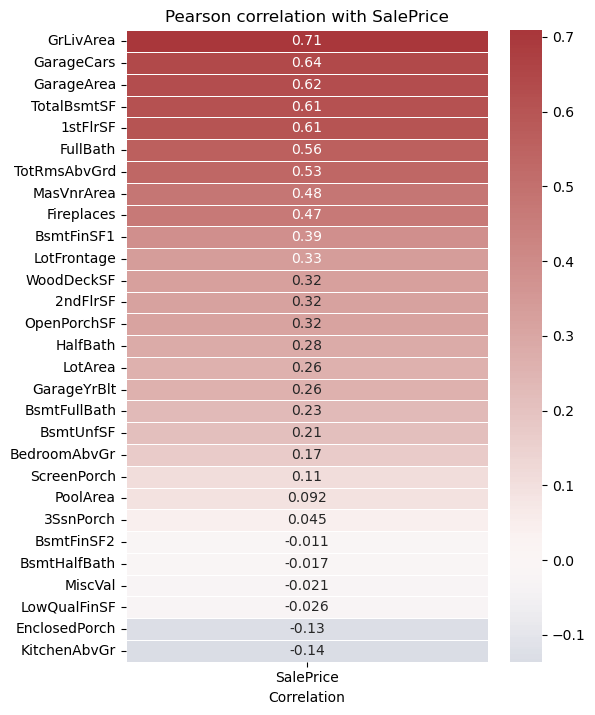

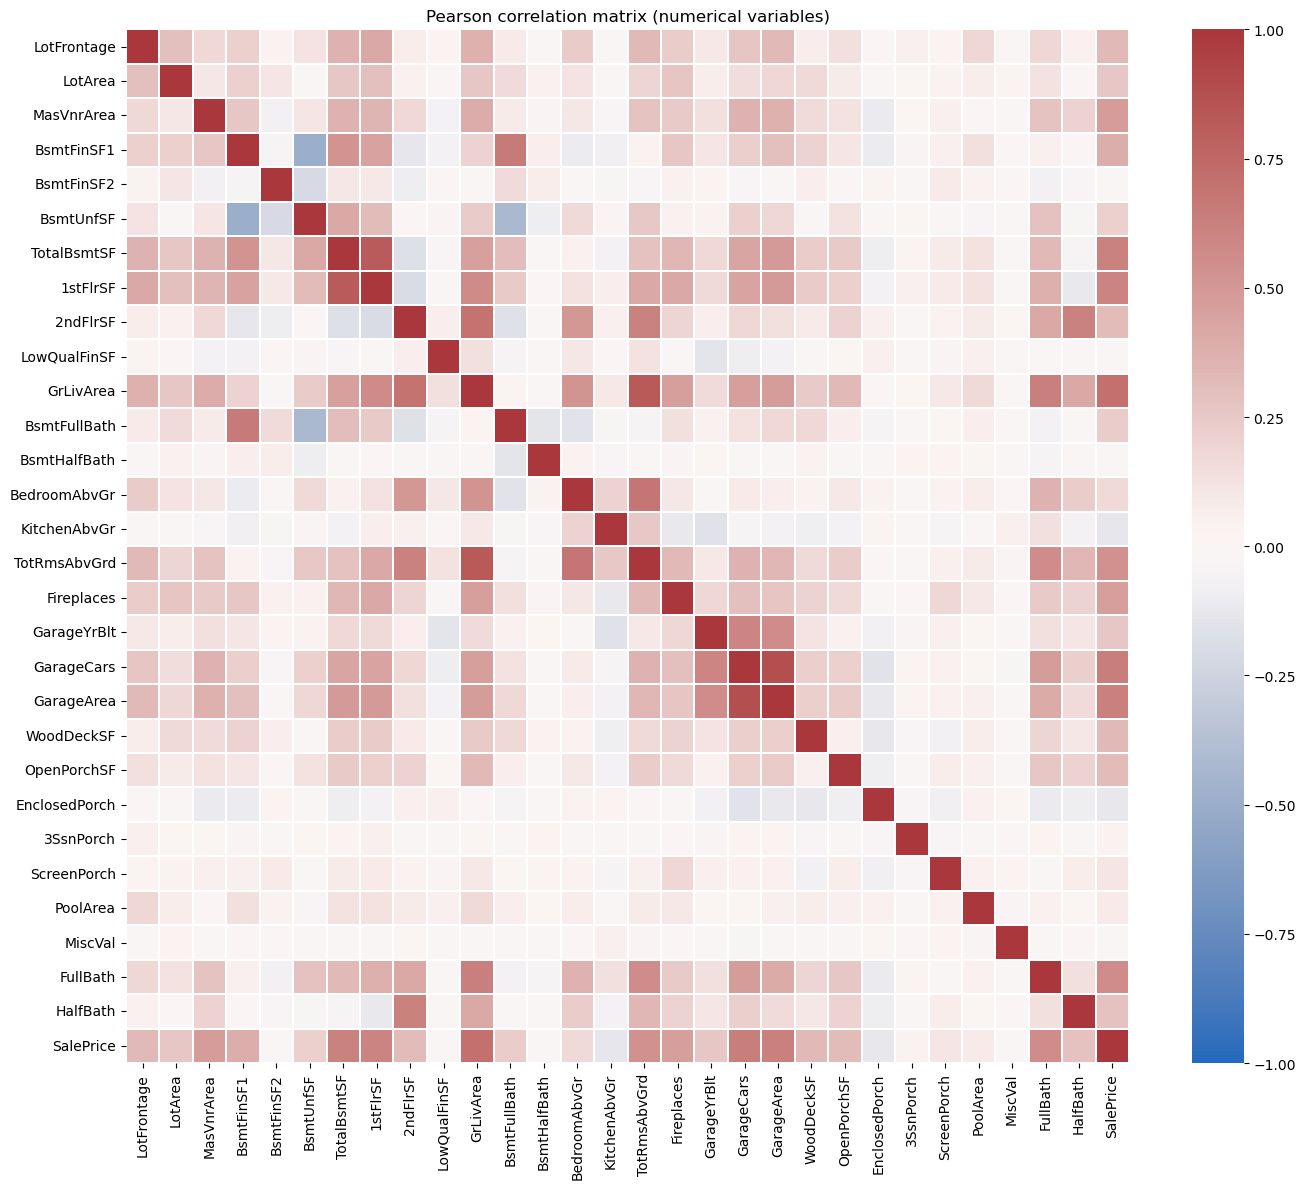

In [16]:
# Heatmaps: Pearson correlation with SalePrice and among numerical variables
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ensure numerical_cols is available in the notebook scope
cols = numerical_cols.copy()
if 'SalePrice' not in cols:
    cols = cols + ['SalePrice']

# compute Pearson correlation matrix
corr_matrix = houses[cols].corr(method='pearson')

# 1) Correlation of numerical variables with SalePrice
corr_with_target = corr_matrix['SalePrice'].drop('SalePrice')
corr_with_target = corr_with_target.sort_values(ascending=False)
plt.figure(figsize=(6, max(4, len(corr_with_target)*0.25)))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='vlag', center=0, linewidths=0.5)
plt.title('Pearson correlation with SalePrice')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# 2) Heatmap of correlation matrix among numerical variables
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='vlag', center=0, vmax=1, vmin=-1, linewidths=0.25)
plt.title('Pearson correlation matrix (numerical variables)')
plt.tight_layout()
plt.show()

Coeficiente de Spearman:

The Spearman correlation coefficient is defined as the Pearson correlation coefficient between the rank variables.
Ranking is a data transformation in which numerical or ordinal data are replaced by their rank when the data are sorted.

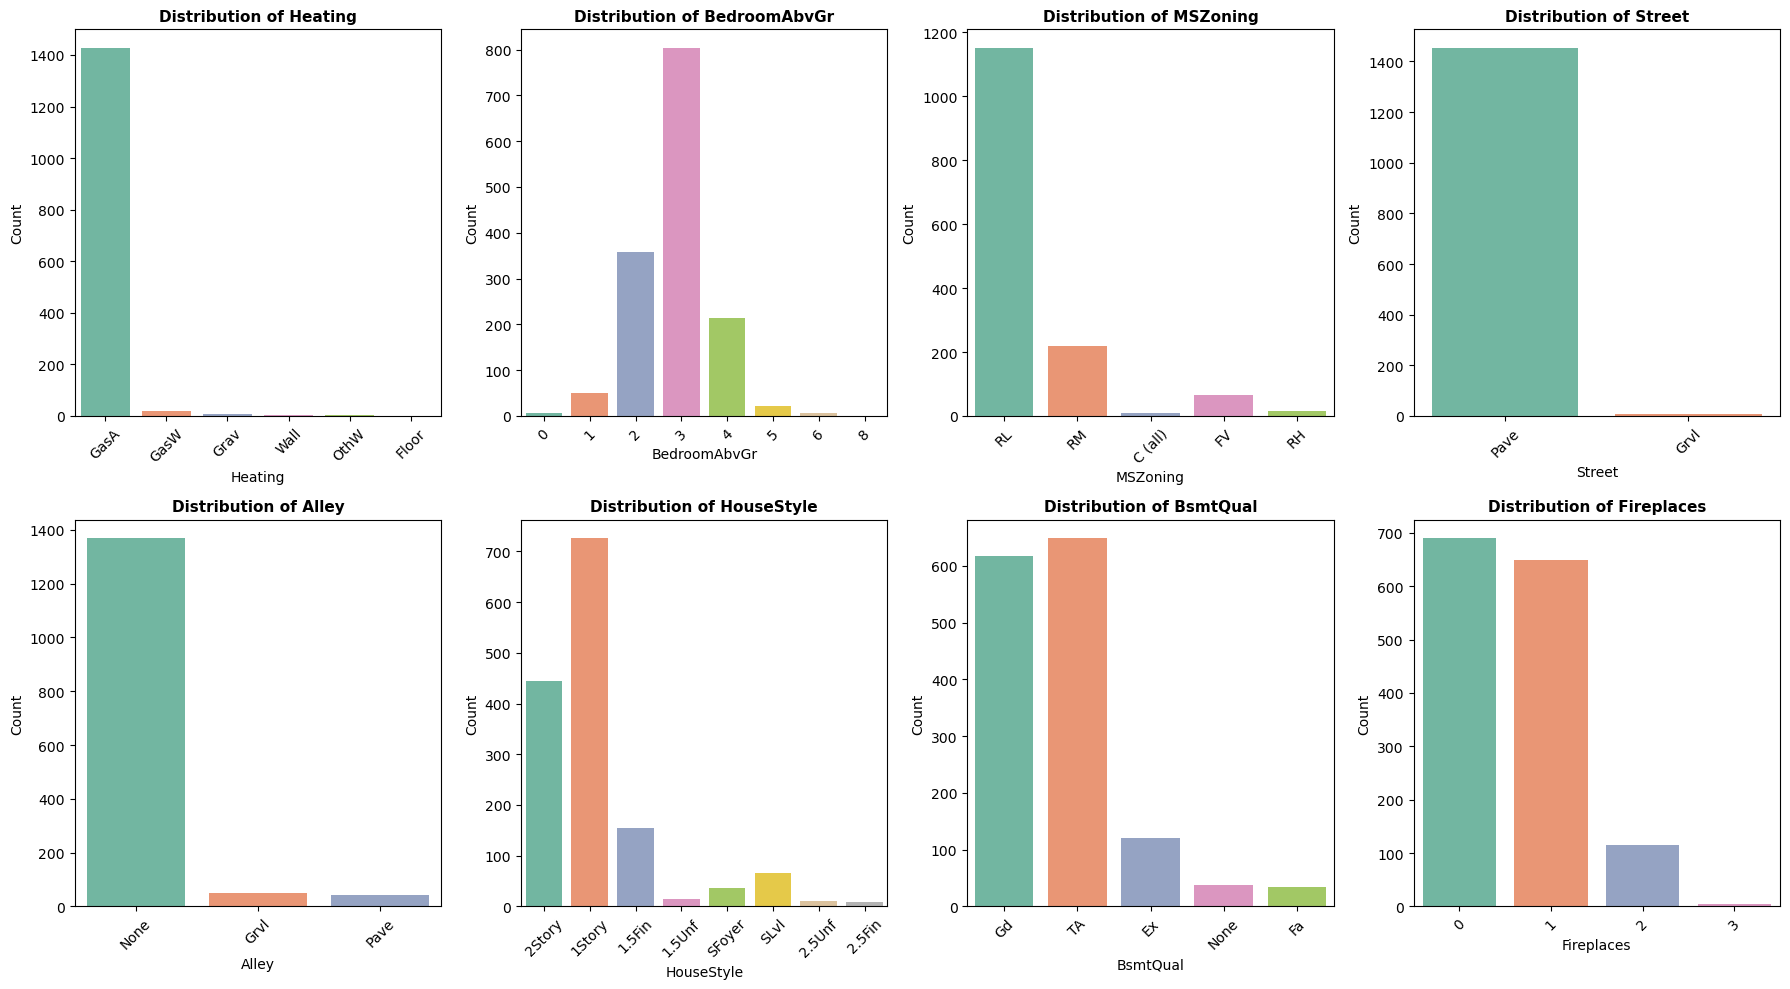

In [17]:
# Create histograms (countplots) for each categorical variable
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'BedroomAbvGr', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtQual', 'Fireplaces']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], palette='Set2', hue=var, legend=False)
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


`Neighborhood`: Locais físicos dentro dos limites da cidade de Ames

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker

In [18]:
# Check missing values in Neighborhood before plotting
missing_neighborhood = houses['Neighborhood'].isna().sum()
print(f'Missing values in Neighborhood: {missing_neighborhood}')

houses['Neighborhood'].value_counts(dropna=False)

Missing values in Neighborhood: 0


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

/tmp/ipykernel_1263/651630342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')


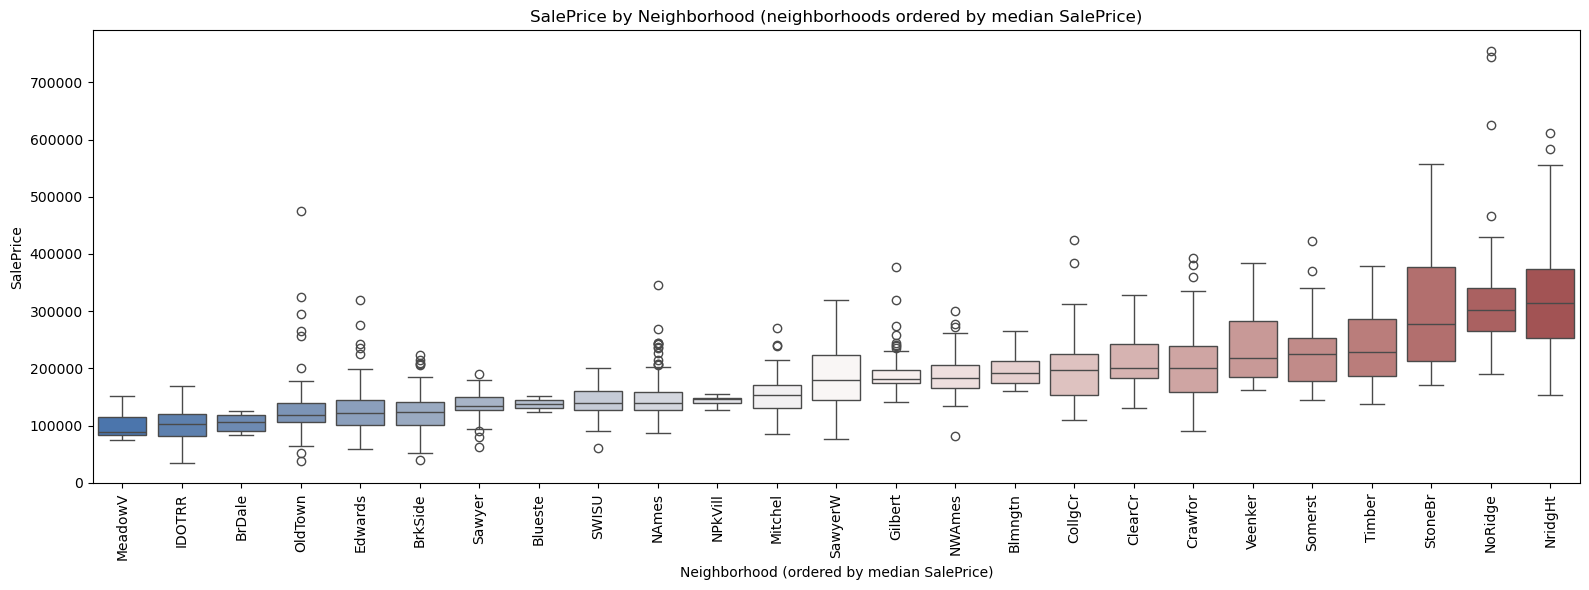

In [19]:
# Boxplot of SalePrice by Neighborhood ordered by median SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

# compute neighborhood medians and order neighborhoods from smallest to largest median
neigh_medians = houses.groupby('Neighborhood')['SalePrice'].median().sort_values()
order = neigh_medians.index

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood (neighborhoods ordered by median SalePrice)')
plt.xlabel('Neighborhood (ordered by median SalePrice)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

O que fazer com bairros que possuem poucas instâncias??
- Agrupar num grupo "Outros"? --> usar mediana??

Bairros com menos de 30 instâncias
- ``Blueste``
- ``NPkVill``
- ``Veenker``
- ``BrDale``
- ``MeadowV``
- ``Blmngtn``
- ``StoneBr``
- ``SWISU``
- ``ClearCr``

In [20]:
# 1) Check missing values and basic stats for GrLivArea
missing_grliv = houses['GrLivArea'].isna().sum()
print(f"Missing values in GrLivArea: {missing_grliv}")

# Show summary statistics to get a sense of distribution and outliers
houses['GrLivArea'].describe()


Missing values in GrLivArea: 0


count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

Pearson correlation: 0.709
Spearman correlation: 0.731
Kendall correlation: 0.544


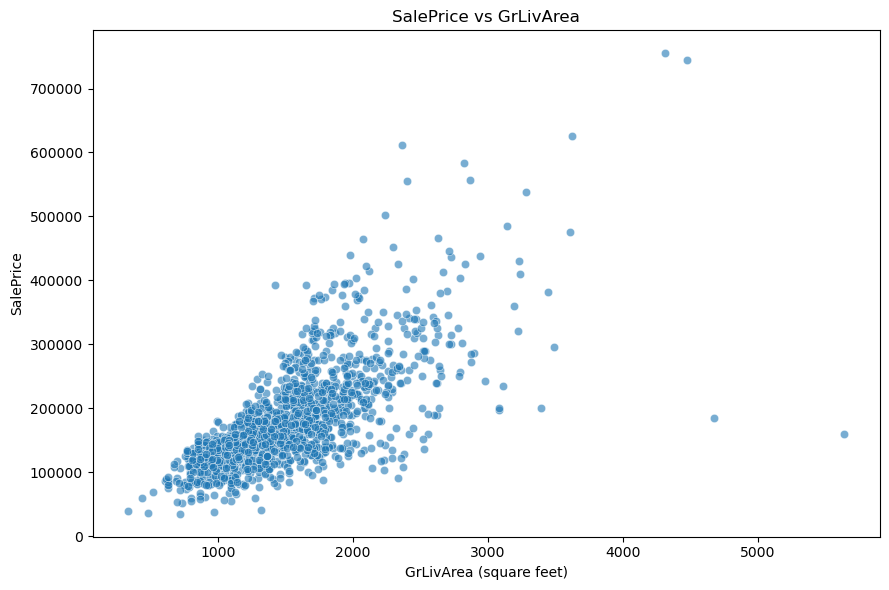

In [21]:
# Calculating correlations and plotting SalePrice vs GrLivArea
import matplotlib.pyplot as plt
import seaborn as sns

# compute Pearson, Spearman, and Kendall correlations
pearson_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='pearson')
spearman_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='spearman')
kendall_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='kendall')

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Kendall correlation: {kendall_corr:.3f}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=houses, x='GrLivArea', y='SalePrice', alpha=0.6)
plt.title('SalePrice vs GrLivArea')
plt.xlabel('GrLivArea (square feet)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

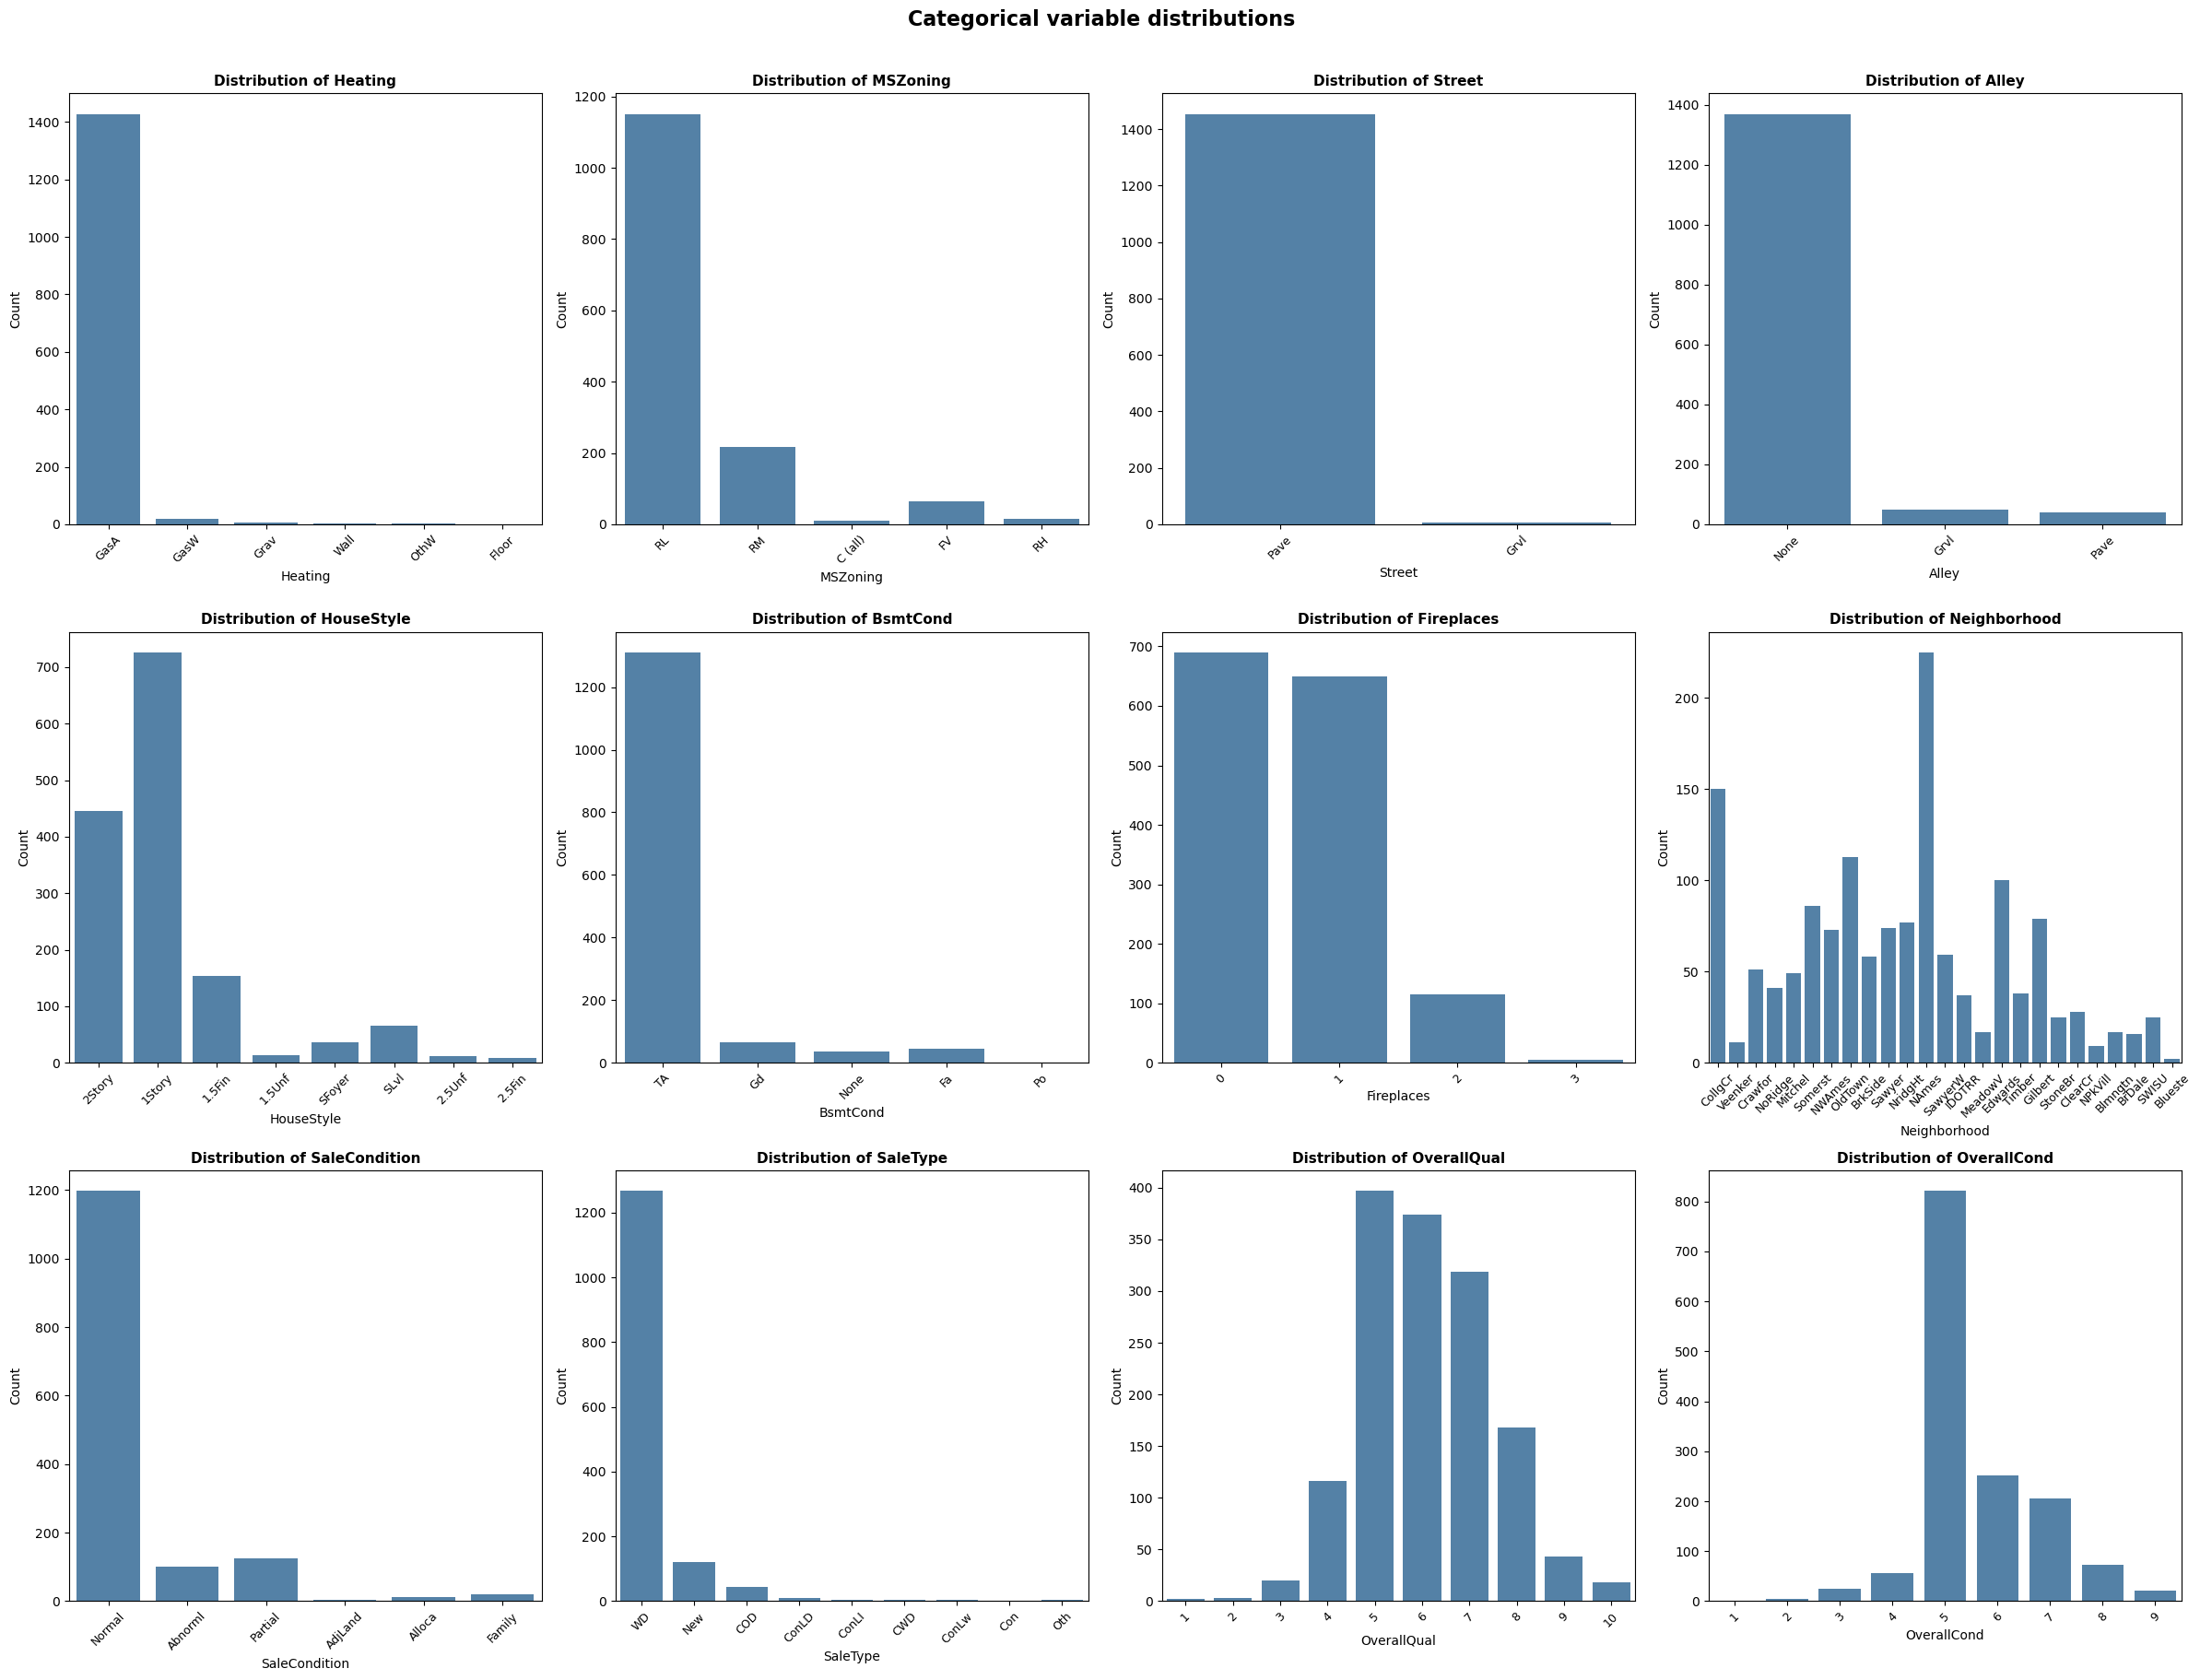

In [22]:
# Create categorical distribution plots with Count on the y axis
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtCond', 'Fireplaces', 'Neighborhood', 'SaleCondition', 'SaleType', 'OverallQual', 'OverallCond']

fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)

for idx in range(len(variables), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical variable distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

histograms for BedroomAbvGr (numeric or ordinal?)